In [1]:
import numpy as np
from scipy.special import factorial
from scipy.stats import binned_statistic

In [2]:
import matplotlib.pyplot as plt

In [3]:
import scipy as sp

In [4]:
import sys
sys.path.append(r"C:/Users/xylin/Documents/Researches/multiphonon-direct-detection/StructureFactor1D.py")
from StructureFactor1D import StructureFactor1D

In [5]:
def get_q_lim(mass_DM, omega_threshold=10e-6):
    v_max = 0.00247 # in c
    q_min = mass_DM * v_max * (1 - np.sqrt(1-2*omega_threshold/(mass_DM * (v_max**2))))
    q_max = mass_DM * v_max * (1 + np.sqrt(1-2*omega_threshold/(mass_DM * (v_max**2))))
    return  q_min, q_max

def get_omega_lim(mass_DM, q,): 
    v_max = 0.00247 # in c
    return q * v_max - q**2 / (2 * mass_DM)


In [6]:
def get_impulse_approx(q, omega_list, omega_avg=40e-6, ):
    mass=26161e3 # sillicon, keV
    latticeConst= 2*np.pi/2.28 # si, keV^-3
    deltasq = q**2 * omega_avg/(2*mass)
    return 28**2 / ((latticeConst**3)/4) * np.sqrt(2*np.pi/deltasq) * np.exp(- (omega_list-(q**2/(2*mass)))**2 / (2*deltasq)) # uses averaged omega (not inverse of averaged inverse)


get s factor

In [7]:
np.sqrt(2*26161e3*13.13e-6)

26.210453258194523

In [8]:
max_omega = 1300*1e-6
omegalength = 4000
omegalist = np.linspace(0, max_omega,omegalength, ) 
qscale = np.sqrt(2*26161e3*13.13e-6) # uses averaged omega (not inverse of averaged inverse)
qlenth = 4000
qlist = np.linspace(0.01, 1e3, qlenth) # 2.5 sqrt(2m omega_bar)
2.5*qscale
q_list_nSite = qlist
omega_list_nSite = omegalist


In [9]:
omgplus = 20e-6 #keV
omgminus = 60e-6 #keV
bins =  omegalist
dw = qlist**2/(8*26161e3)*(1/omgplus+1/omgminus)

In [10]:
# get n and j combo
nlist = np.arange(1,int(max_omega/omgplus)+1)
col1 = np.repeat(nlist, nlist+1) 
col2 = np.concatenate([np.arange(n + 1) for n in nlist])
pairs = np.column_stack((col1, col2))
mask = ( (pairs[:,0]-pairs[:,1])*omgminus + pairs[:,1]*omgplus ) < max_omega
pairs = pairs[mask]

In [11]:
omegalist_nobin = (pairs[:,0]-pairs[:,1])*omgminus + pairs[:,1]*omgplus
# omegalist_nobin

In [12]:
s_diag_nobin = 1/(2*(2*np.pi/2.28)**3) * np.exp(-2*dw)[:,np.newaxis] * (
    (qlist[:,np.newaxis]**2/(4*26161e3))**pairs[:,0] *2*np.pi/(factorial(pairs[:,1])*factorial(pairs[:,0]-pairs[:,1])* (omgminus**(pairs[:,0]-pairs[:,1])) * omgplus**pairs[:,1] )
)

In [13]:
s_offdiag_nobin = 1/(2*(2*np.pi/2.28)**3)* (np.cos(qlist*(2*np.pi/2.28))[:,np.newaxis]) * np.exp(-2*dw)[:,np.newaxis] * ((-1)**((pairs[:,0]-pairs[:,1]))*(qlist[:,np.newaxis]**2/(4*26161e3))**pairs[:,0] *2*np.pi/(factorial(pairs[:,1])*factorial(pairs[:,0]-pairs[:,1])* (omgminus**(pairs[:,0]-pairs[:,1])) * omgplus**pairs[:,1] )
)

In [14]:
resultdiag = binned_statistic(omegalist_nobin, s_diag_nobin, statistic="sum",bins=bins, range=(min(omegalist), max(omegalist)))
xlist = resultdiag.bin_edges[:-1]
sfactordiag = resultdiag.statistic/(xlist[1]-xlist[0]) * (28**2) * 2

In [15]:
resulttot = binned_statistic(omegalist_nobin, s_diag_nobin+s_offdiag_nobin, statistic="sum",bins=bins, range=(min(omegalist), max(omegalist)))
xlist = resulttot.bin_edges[:-1]
sfactortot = resulttot.statistic/(xlist[1]-xlist[0]) * (28**2) * 2


In [16]:
sfactortot.shape

(4000, 3999)

In [17]:
def get_impulse_approx(q, omega_list, omega_avg=13.13e-6, ):
    mass=26161e3 # sillicon, keV
    latticeConst= 2*np.pi/2.28 # si, keV^-3
    deltasq = q**2 * omega_avg/(2*mass)
    return 28**2 / ((latticeConst**3)/4) * np.sqrt(2*np.pi/deltasq) * np.exp(- (omega_list-(q**2/(2*mass)))**2 / (2*deltasq)) # uses averaged omega (not inverse of averaged inverse)

Text(0.5, 1.0, 'q=75.0 keV')

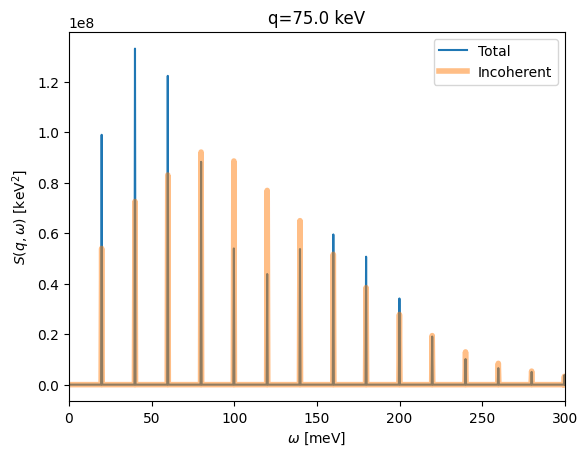

In [18]:
ind = 300
ia = get_impulse_approx(qlist[ind],omegalist,omega_avg=40e-6)
# plt.plot(omegalist*1e6,ia*14,color="gray")
plt.plot(xlist*1e6,sfactortot[ind],alpha=1,label="Total")
plt.plot(xlist*1e6,sfactordiag[ind],alpha=0.5, lw=4,label="Incoherent")
plt.xlabel("$\omega$ [meV]")
plt.ylabel("$S(q,\omega)$ [keV$^2$]")
plt.xlim(0,300)
plt.legend()
plt.title(f"q={qlist[ind]:.1f} keV")

# ind = 300
# ia = get_impulse_approx(qlist[ind],omegalist,omega_avg=40e-6)
# # plt.plot(omegalist*1e6,ia*14,color="gray")
# plt.plot(omegalist*1e6,sfactortot[ind],alpha=1,label="Total")
# plt.plot(omegalist*1e6,sfactordiag[ind],alpha=0.5, lw=4,label="Incoherent")
# plt.xlabel("$\omega$ [meV]")
# plt.ylabel("$S(q,\omega)$ [keV$^2$]")
# plt.xlim(0,300)
# plt.legend()
# plt.title(f"q={qlist[ind]:.1f} keV")

# plt.plot(qlist,s_diag_nobin[:,0]+s_diag_nobin[:,1]+s_offdiag_nobin[:,0]+s_offdiag_nobin[:,1])

In [19]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'stix', 
    'font.size': 17              
})

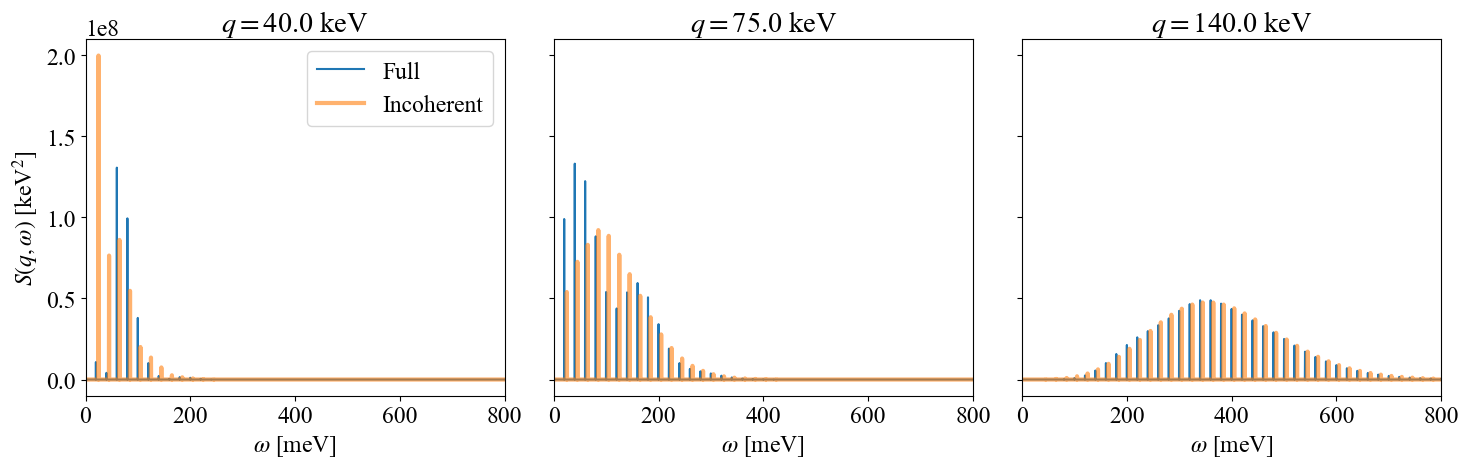

In [22]:
indices = [160, 300, 560]

# Create a figure with 1 row and 3 columns of subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5),sharey=True)


for i, ind in enumerate(indices):
    ax = axes[i]  # Select the current subplot axis
    
    # Calculate the impulse approximation (currently unused in the plot, but kept for your reference)
    ia = get_impulse_approx(qlist[ind], omegalist, omega_avg=40e-6)
    # ax.plot(omegalist*1e6, ia*14, color="gray", label="Impulse Approx")
    
    # Plot the data on the specific subplot axis 'ax' instead of 'plt'
    ax.plot(xlist*1e6, sfactortot[ind], alpha=1, label="Full")
    ax.plot(xlist*1e6+5, sfactordiag[ind], alpha=0.6, lw=3, label="Incoherent")
    
    ax.set_xlabel(r"$\omega$ [meV]")
    
    # Optional: Only show the y-label on the first (left-most) plot to reduce clutter
    if i == 0:
        ax.set_ylabel(r"$S(q,\omega)$ [keV$^2$]")
        ax.legend()

        
    ax.set_xlim(0, 800)
    ax.set_title(f"$q=${qlist[ind]:.1f} keV")

# Automatically adjust the spacing between subplots so labels don't overlap
plt.tight_layout()
plt.show()

In [21]:
np.round(xlist[np.nonzero(sfactortot[0])[0]]*1e6)

array([  20.,   40.,   60.,   80.,  100.,  120.,  140.,  160.,  180.,
        200.,  220.,  240.,  260.,  280.,  300.,  320.,  340.,  360.,
        380.,  400.,  420.,  440.,  460.,  480.,  500.,  520.,  540.,
        560.,  580.,  600.,  620.,  640.,  660.,  680.,  700.,  720.,
        740.,  760.,  780.,  800.,  820.,  840.,  860.,  880.,  900.,
        920.,  940.,  960.,  980., 1000., 1020., 1040., 1060., 1080.,
       1100., 1120., 1140., 1160., 1180., 1200., 1220., 1240., 1260.,
       1280.])